In [30]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

## 1. Load & Eksplorasi Awal Data


In [31]:
df_raw = pd.read_csv('loan_data_2007_2014.csv', low_memory=False)
print(f"Jumlah baris  : {len(df_raw):,}")
print(f"Jumlah kolom  : {df_raw.shape[1]}")
print()
print("Distribusi loan_status (status pinjaman):")
print(df_raw['loan_status'].value_counts())


Jumlah baris  : 466,285
Jumlah kolom  : 75

Distribusi loan_status (status pinjaman):
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [33]:
df_raw.head(3)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Status Nasabah Baik vs Nasabah Buruk

In [5]:
# Definisikan status yang jelas 
good_status = {'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid'}
bad_status  = {
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'
}

df = df_raw[df_raw['loan_status'].isin(good_status | bad_status)].copy()
df['target'] = df['loan_status'].apply(lambda x: 0 if x in good_status else 1)

print(f"Data setelah filter: {len(df):,} baris")
print()
print(df['target'].value_counts().rename({0:'Nasabah Baik (0)', 1:'Nasabah Buruk (1)'}))
print()
bad_rate = df['target'].mean()
print(f"Default Rate (tingkat gagal bayar): {bad_rate:.1%}")


Data setelah filter: 237,695 baris

target
Nasabah Baik (0)     186727
Nasabah Buruk (1)     50968
Name: count, dtype: int64

Default Rate (tingkat gagal bayar): 21.4%


## 3. Exploratory Data Analysis (EDA)


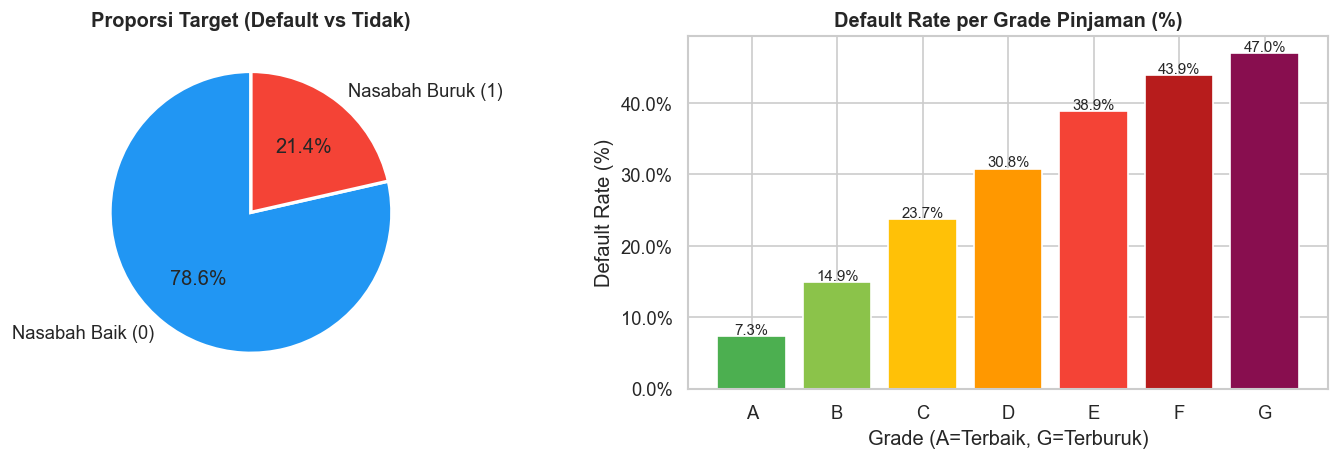

In [34]:
# Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df['target'].value_counts()
axes[0].pie(counts, labels=['Nasabah Baik (0)', 'Nasabah Buruk (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proporsi Target (Default vs Tidak)', fontweight='bold')

# Bar chart default rate by grade
grade_default = df.groupby('grade')['target'].mean().sort_index()
axes[1].bar(grade_default.index, grade_default.values * 100,
            color=['#4CAF50','#8BC34A','#FFC107','#FF9800','#F44336','#B71C1C','#880E4F'])
axes[1].set_title('Default Rate per Grade Pinjaman (%)', fontweight='bold')
axes[1].set_xlabel('Grade (A=Terbaik, G=Terburuk)')
axes[1].set_ylabel('Default Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(grade_default.values):
    axes[1].text(i, v*100 + 0.3, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

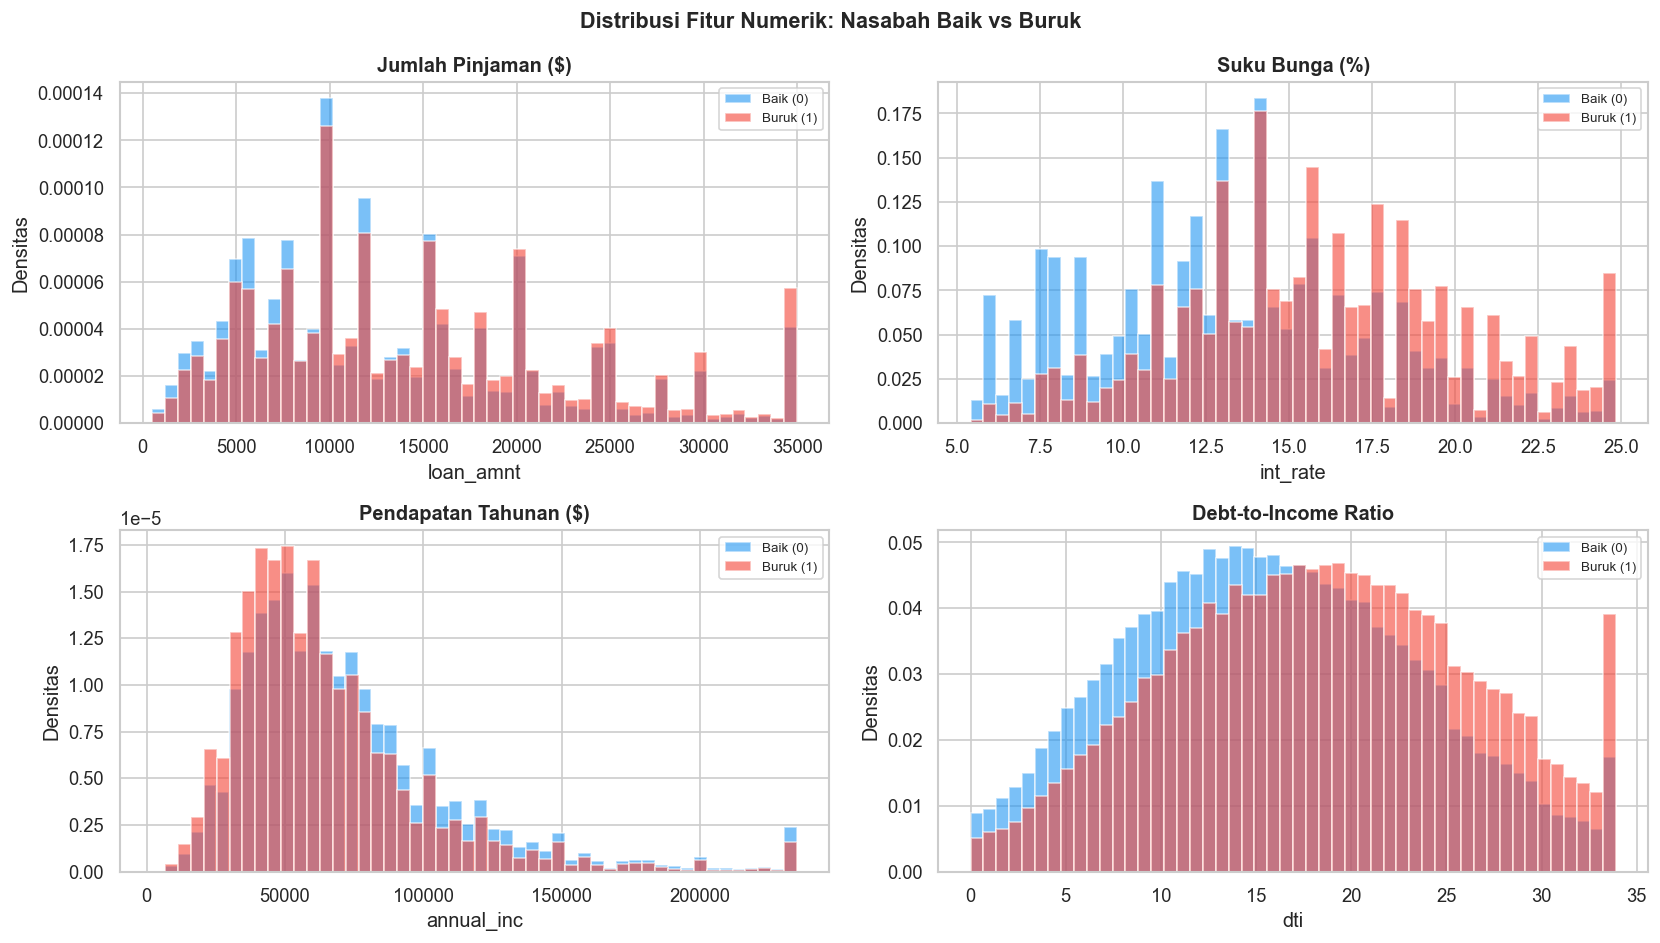

In [35]:
# --- Distribusi fitur numerik utama ---
features_plot = {
    'loan_amnt'  : 'Jumlah Pinjaman ($)',
    'int_rate'   : 'Suku Bunga (%)',
    'annual_inc' : 'Pendapatan Tahunan ($)',
    'dti'        : 'Debt-to-Income Ratio'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (col, label) in zip(axes.flatten(), features_plot.items()):
    tmp = df[[col, 'target']].dropna()
    tmp_good = tmp[tmp['target'] == 0][col]
    tmp_bad  = tmp[tmp['target'] == 1][col]

    # Clip outlier ekstrem untuk visualisasi
    p99 = tmp[col].quantile(0.99)
    tmp_good = tmp_good.clip(upper=p99)
    tmp_bad  = tmp_bad.clip(upper=p99)

    ax.hist(tmp_good, bins=50, alpha=0.6, color='#2196F3', label='Baik (0)', density=True)
    ax.hist(tmp_bad,  bins=50, alpha=0.6, color='#F44336', label='Buruk (1)', density=True)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik: Nasabah Baik vs Buruk', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


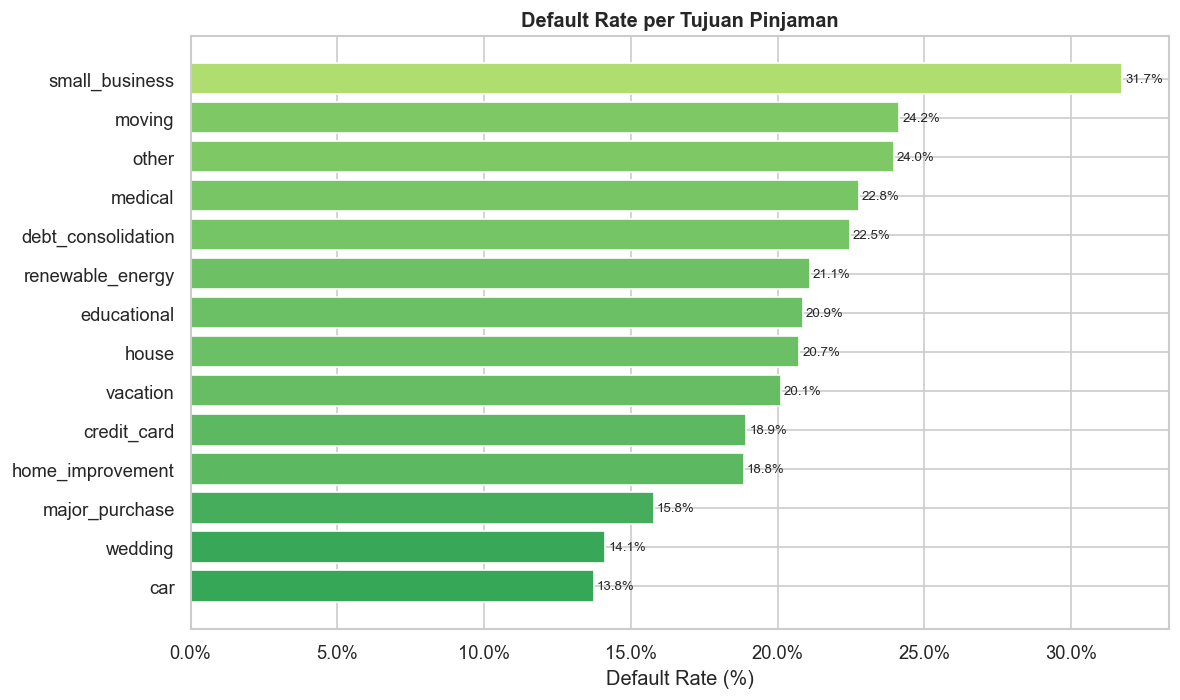

In [36]:
# --- Default rate by tujuan pinjaman ---
purpose_default = (df.groupby('purpose')['target']
                   .agg(['mean','count'])
                   .rename(columns={'mean':'default_rate','count':'jumlah'})
                   .sort_values('default_rate', ascending=True))
purpose_default['default_pct'] = purpose_default['default_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(purpose_default.index, purpose_default['default_pct'],
               color=plt.cm.RdYlGn_r(purpose_default['default_rate']))
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate per Tujuan Pinjaman', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, purpose_default['default_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()


In [37]:
# ─── Pilih fitur yang valid secara bisnis ─────────────────────────────────
# Hanya fitur yang ada SEBELUM pinjaman disetujui (pre-approval features)

FEATURES_FINAL = [
    # Informasi pinjaman
    'loan_amnt',          
    'term',              
    'int_rate',           
    'installment',        
    'purpose',            

    # Informasi nasabah
    'emp_length',         
    'home_ownership',     
    'annual_inc',         
    'verification_status',
    'dti',            

    # Riwayat kredit
    'delinq_2yrs',        
    'earliest_cr_line',   
    'inq_last_6mths',     
    'mths_since_last_delinq',
    'mths_since_last_record',
    'open_acc',           
    'pub_rec',            
    'revol_bal',          
    'revol_util',         
    'total_acc',          
    'collections_12_mths_ex_med',  
    'acc_now_delinq',     
    'tot_cur_bal',        
    'total_rev_hi_lim',   
    'addr_state',         
]

TARGET = 'target'

print(f"Jumlah fitur yang dipilih: {len(FEATURES_FINAL)}")
print("\nFitur yang dipilih:")
for f in FEATURES_FINAL:
    print(f"  - {f}")


Jumlah fitur yang dipilih: 25

Fitur yang dipilih:
  - loan_amnt
  - term
  - int_rate
  - installment
  - purpose
  - emp_length
  - home_ownership
  - annual_inc
  - verification_status
  - dti
  - delinq_2yrs
  - earliest_cr_line
  - inq_last_6mths
  - mths_since_last_delinq
  - mths_since_last_record
  - open_acc
  - pub_rec
  - revol_bal
  - revol_util
  - total_acc
  - collections_12_mths_ex_med
  - acc_now_delinq
  - tot_cur_bal
  - total_rev_hi_lim
  - addr_state


In [38]:
# Subset dan Bersihkan Data 
df_model = df[FEATURES_FINAL + [TARGET]].copy()

print("Missing values sebelum cleaning:")
missing = df_model.isnull().mean()
print(missing[missing > 0].sort_values(ascending=False))


Missing values sebelum cleaning:
mths_since_last_record        0.879072
mths_since_last_delinq        0.559507
tot_cur_bal                   0.280174
total_rev_hi_lim              0.280174
emp_length                    0.038520
revol_util                    0.000972
collections_12_mths_ex_med    0.000610
total_acc                     0.000122
earliest_cr_line              0.000122
delinq_2yrs                   0.000122
inq_last_6mths                0.000122
open_acc                      0.000122
pub_rec                       0.000122
acc_now_delinq                0.000122
annual_inc                    0.000017
dtype: float64


## 4. Feature Engineering

In [39]:
# ─── Feature Engineering ──────────────────────────────────────────────────

# 1. TERM: Ubah '36 months' → 36 (angka)
df_model['term'] = df_model['term'].str.extract(r'(\d+)').astype(float)

# 2. EMP_LENGTH: Ubah teks menjadi angka
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df_model['emp_length'] = df_model['emp_length'].map(emp_map)
df_model['emp_length'].fillna(df_model['emp_length'].median(), inplace=True)

# 3. EARLIEST_CR_LINE → Credit Age (usia kredit dalam tahun)
REF_YEAR = 2015
def parse_cr_year(date_str):
    try:
        return int(str(date_str).split('-')[1])
    except:
        return np.nan

df_model['credit_age_years'] = df_model['earliest_cr_line'].apply(parse_cr_year)
df_model['credit_age_years'] = REF_YEAR - df_model['credit_age_years']
df_model['credit_age_years'] = df_model['credit_age_years'].clip(0, 80)
df_model.drop(columns=['earliest_cr_line'], inplace=True)

# 4. FITUR BARU: Rasio-rasio tambahan yang bermakna bisnis
df_model['loan_to_income'] = df_model['loan_amnt'] / (df_model['annual_inc'] + 1)
df_model['installment_to_income'] = df_model['installment'] / (df_model['annual_inc'] / 12 + 1)
df_model['revol_bal_to_limit'] = df_model['revol_bal'] / (df_model['total_rev_hi_lim'] + 1)

# 5. MTHS_SINCE_LAST_DELINQ: Isi NaN dengan nilai besar (artinya tidak pernah terlambat)
df_model['mths_since_last_delinq'].fillna(999, inplace=True)
df_model['mths_since_last_record'].fillna(999, inplace=True)

# 6. Fitur lain
numeric_cols = df_model.select_dtypes(include='number').columns
for col in numeric_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

# 7. ENKODING VARIABEL KATEGORIKAL
cat_cols = ['term', 'purpose', 'emp_length', 'home_ownership', 
            'verification_status', 'addr_state']
cat_cols = [c for c in cat_cols if c in df_model.columns and str(df_model[c].dtype) in ['object', 'string', 'category', 'str']]

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"Jumlah fitur setelah encoding: {df_model.shape[1] - 1}")
print(f"Jumlah baris: {len(df_model):,}")
print()
print("Missing values setelah cleaning:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Jumlah fitur setelah encoding: 93
Jumlah baris: 237,695

Missing values setelah cleaning:
emp_length                      9156
annual_inc                         4
delinq_2yrs                       29
inq_last_6mths                    29
mths_since_last_delinq        132992
mths_since_last_record        208951
open_acc                          29
pub_rec                           29
revol_util                       231
total_acc                         29
collections_12_mths_ex_med       145
acc_now_delinq                    29
tot_cur_bal                    66596
total_rev_hi_lim               66596
credit_age_years                  29
loan_to_income                     4
installment_to_income              4
revol_bal_to_limit             66596
dtype: int64


## 5. Pembagian Data: Train / Validation / Test


In [41]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Split 60/20/20 secara stratified
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# 0.25 dari 80% = 20% keseluruhan

print(f"Train set  : {len(X_train):,} baris ({y_train.mean():.1%} default rate)")
print(f"Val set    : {len(X_val):,} baris  ({y_val.mean():.1%} default rate)")
print(f"Test set   : {len(X_test):,} baris  ({y_test.mean():.1%} default rate)")


Train set  : 142,617 baris (21.4% default rate)
Val set    : 47,539 baris  (21.4% default rate)
Test set   : 47,539 baris  (21.4% default rate)


## 6. Pemodelan HistGradientBoostingClassifier


In [42]:
base_model = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=6,
    learning_rate=0.05,
    min_samples_leaf=50,
    l2_regularization=0.1,
    random_state=42
)

base_model.fit(X_train, y_train)

# Evaluasi di validation set
y_val_proba_base = base_model.predict_proba(X_val)[:, 1]
auc_base = roc_auc_score(y_val, y_val_proba_base)

# KS Statistic (pisahnya distribusi skor baik vs buruk)
fpr, tpr, _ = roc_curve(y_val, y_val_proba_base)
ks_base = max(tpr - fpr)

print(f"\n  Base Model — Validation Set:")
print(f"  ROC-AUC : {auc_base:.4f}")
print(f"  KS Stat : {ks_base:.2%}")



  Base Model — Validation Set:
  ROC-AUC : 0.7177
  KS Stat : 31.98%


In [44]:
# Kalibrasi Probabilitas
from sklearn.frozen import FrozenEstimator
calibrated_model = CalibratedClassifierCV(estimator=FrozenEstimator(base_model), method='sigmoid')
calibrated_model.fit(X_val, y_val)

# Evaluasi di test set (data yang belum pernah dilihat model)
y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]
auc_final = roc_auc_score(y_test, y_test_proba)
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_proba)
ks_final = max(tpr_t - fpr_t)

print(f"  Model Terkalibrasi — Test Set:")
print(f"  ROC-AUC : {auc_final:.4f}")
print(f"  KS Stat : {ks_final:.2%}")

  Model Terkalibrasi — Test Set:
  ROC-AUC : 0.7162
  KS Stat : 31.67%


## 7. Visualisasi Evaluasi Model

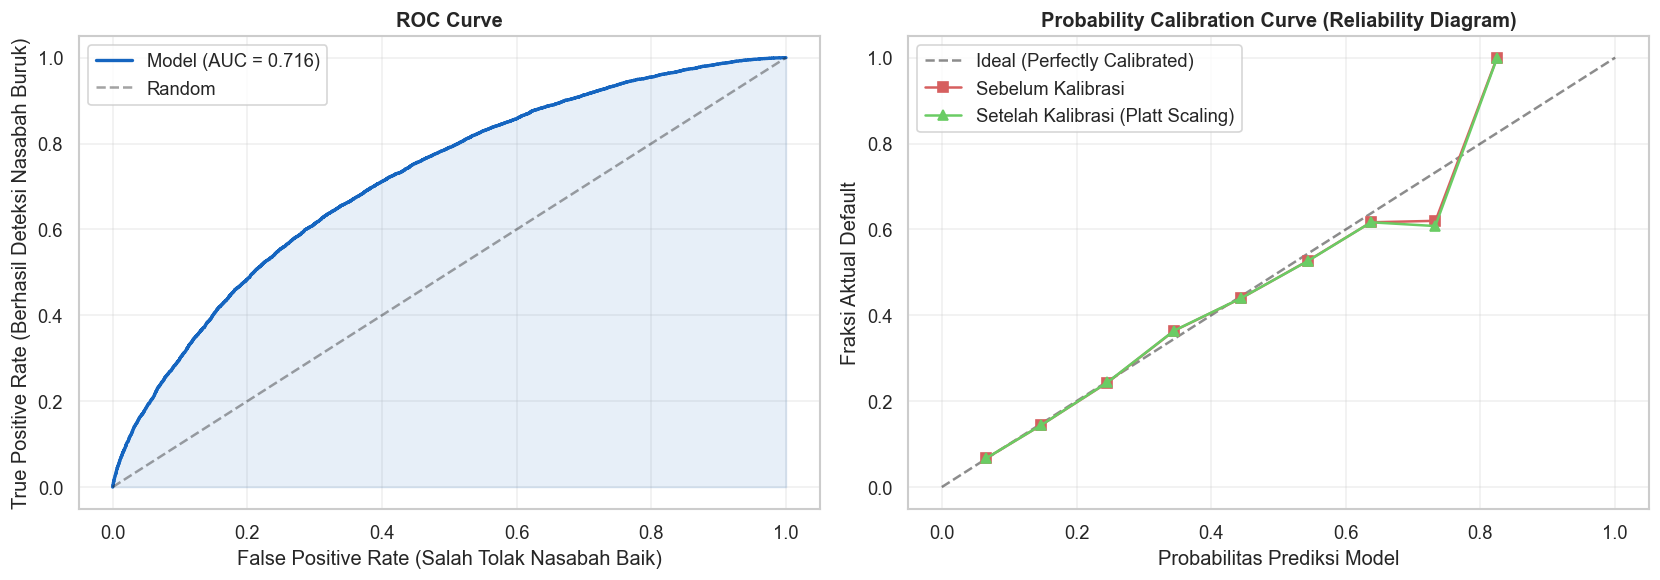

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ROC Curve
axes[0].plot(fpr_t, tpr_t, color='#1565C0', lw=2, 
             label=f'Model (AUC = {auc_final:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].fill_between(fpr_t, tpr_t, alpha=0.1, color='#1565C0')
axes[0].set_xlabel('False Positive Rate (Salah Tolak Nasabah Baik)')
axes[0].set_ylabel('True Positive Rate (Berhasil Deteksi Nasabah Buruk)')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calibration Curve
y_val_proba_base_val = base_model.predict_proba(X_val)[:, 1]
y_val_proba_cal  = calibrated_model.predict_proba(X_val)[:, 1]

frac_pos_base, mean_pred_base = calibration_curve(y_val, y_val_proba_base_val, n_bins=10)
frac_pos_cal, mean_pred_cal   = calibration_curve(y_val, y_val_proba_cal, n_bins=10)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Ideal (Perfectly Calibrated)')
axes[1].plot(mean_pred_base, frac_pos_base, 'rs-', label='Sebelum Kalibrasi')
axes[1].plot(mean_pred_cal, frac_pos_cal, 'g^-', label='Setelah Kalibrasi (Platt Scaling)')
axes[1].set_xlabel('Probabilitas Prediksi Model')
axes[1].set_ylabel('Fraksi Aktual Default')
axes[1].set_title('Probability Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Analisis Threshold Keputusan

In [47]:
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

results = []
for thresh in thresholds:
    y_pred = (y_test_proba >= thresh).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'Threshold': thresh,
        'Precision (%)': round(precision * 100, 1),
        'Recall (%)': round(recall * 100, 1),
        'F1 Score': round(f1, 4),
        'Jumlah Ditolak': fp + tp,
        'Nasabah Buruk Tertangkap': tp,
        'Nasabah Baik Salah Tolak': fp
    })

df_thresh = pd.DataFrame(results)
print(df_thresh.to_string(index=False))


 Threshold  Precision (%)  Recall (%)  F1 Score  Jumlah Ditolak  Nasabah Buruk Tertangkap  Nasabah Baik Salah Tolak
      0.15           29.0        83.3    0.4302           29264                      8488                     20776
      0.20           32.9        70.3    0.4487           21759                      7169                     14590
      0.25           37.0        57.8    0.4514           15901                      5890                     10011
      0.30           41.1        44.9    0.4291           11159                      4581                      6578
      0.35           44.3        33.0    0.3784            7593                      3365                      4228
      0.40           48.0        23.7    0.3172            5027                      2414                      2613
      0.45           52.6        16.1    0.2462            3113                      1638                      1475
      0.50           57.3        10.1    0.1716            1797         

# 9. Visualisasi Trade-off

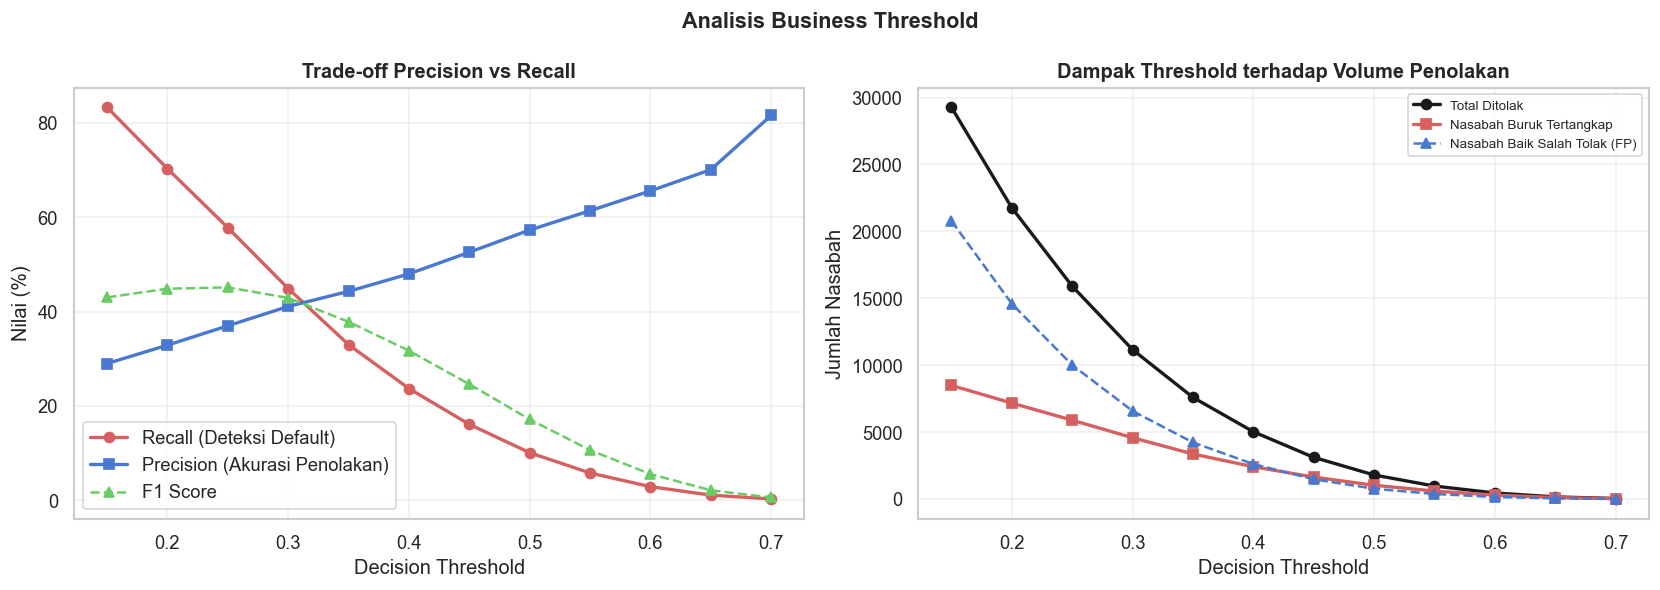

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall-F1 trade-off
axes[0].plot(df_thresh['Threshold'], df_thresh['Recall (%)'],
             'ro-', label='Recall (Deteksi Default)', lw=2)
axes[0].plot(df_thresh['Threshold'], df_thresh['Precision (%)'],
             'bs-', label='Precision (Akurasi Penolakan)', lw=2)
axes[0].plot(df_thresh['Threshold'], df_thresh['F1 Score'] * 100,
             'g^--', label='F1 Score', lw=1.5)
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Nilai (%)')
axes[0].set_title('Trade-off Precision vs Recall', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Jumlah ditolak
axes[1].plot(df_thresh['Threshold'], df_thresh['Jumlah Ditolak'],
             'ko-', label='Total Ditolak', lw=2)
axes[1].plot(df_thresh['Threshold'], df_thresh['Nasabah Buruk Tertangkap'],
             'rs-', label='Nasabah Buruk Tertangkap', lw=2)
axes[1].plot(df_thresh['Threshold'], df_thresh['Nasabah Baik Salah Tolak'],
             'b^--', label='Nasabah Baik Salah Tolak (FP)', lw=1.5)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].set_title('Dampak Threshold terhadap Volume Penolakan', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analisis Business Threshold', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Pemilihan Threshold Optimal & Evaluasi Final

In [49]:
BEST_THRESHOLD = 0.30

y_pred_final = (y_test_proba >= BEST_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print("=" * 65)
print(f"  EVALUASI FINAL (Threshold = {BEST_THRESHOLD})")
print("=" * 65)
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Nasabah Baik (0)', 'Nasabah Buruk (1)']))

print(f"  ROC-AUC Score : {auc_final:.4f}")
print(f"  KS Statistic  : {ks_final:.2%}")
print()
print("─" * 65)
print("  INTERPRETASI BISNIS")
print("─" * 65)
total_bad  = tp + fn
total_good = tn + fp
print(f"  Dari {total_bad:,} Nasabah Buruk:")
print(f"    → Berhasil DITOLAK  : {tp:,} ({tp/total_bad:.1%}) — NPL terselamatkan")
print(f"    → Lolos ke approval : {fn:,} ({fn/total_bad:.1%}) — Risiko NPL tersisa")
print()
print(f"  Dari {total_good:,} Nasabah Baik:")
print(f"    → Berhasil DISETUJUI: {tn:,} ({tn/total_good:.1%}) — Profit bunga masuk")
print(f"    → Salah DITOLAK     : {fp:,} ({fp/total_good:.1%}) — Opportunity cost")


  EVALUASI FINAL (Threshold = 0.3)

                   precision    recall  f1-score   support

 Nasabah Baik (0)       0.85      0.82      0.83     37345
Nasabah Buruk (1)       0.41      0.45      0.43     10194

         accuracy                           0.74     47539
        macro avg       0.63      0.64      0.63     47539
     weighted avg       0.75      0.74      0.75     47539

  ROC-AUC Score : 0.7162
  KS Statistic  : 31.67%

─────────────────────────────────────────────────────────────────
  INTERPRETASI BISNIS
─────────────────────────────────────────────────────────────────
  Dari 10,194 Nasabah Buruk:
    → Berhasil DITOLAK  : 4,581 (44.9%) — NPL terselamatkan
    → Lolos ke approval : 5,613 (55.1%) — Risiko NPL tersisa

  Dari 37,345 Nasabah Baik:
    → Berhasil DISETUJUI: 30,767 (82.4%) — Profit bunga masuk
    → Salah DITOLAK     : 6,578 (17.6%) — Opportunity cost


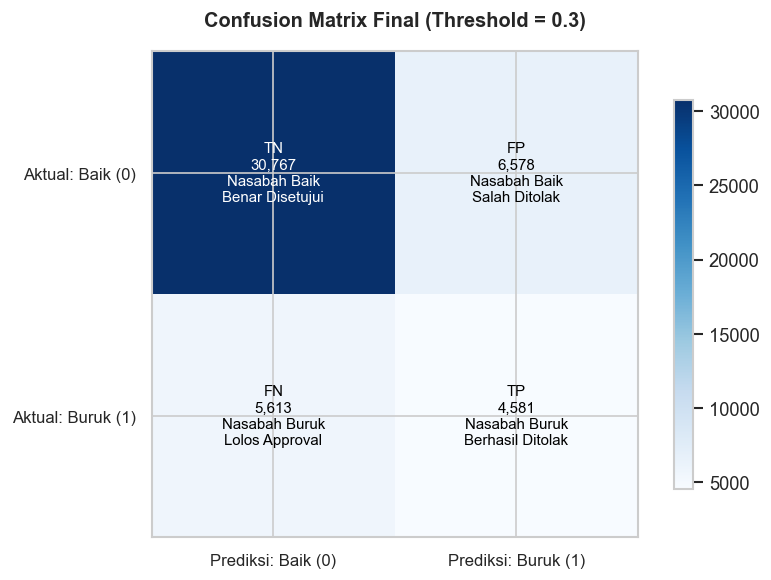

In [50]:
# Confusion Matrix Visual
fig, ax = plt.subplots(figsize=(7, 5))

cm_labels = np.array([[f'TN\n{tn:,}\nNasabah Baik\nBenar Disetujui',
                        f'FP\n{fp:,}\nNasabah Baik\nSalah Ditolak'],
                       [f'FN\n{fn:,}\nNasabah Buruk\nLolos Approval',
                        f'TP\n{tp:,}\nNasabah Buruk\nBerhasil Ditolak']])

cm_values = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm_values, interpolation='nearest', cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Prediksi: Baik (0)', 'Prediksi: Buruk (1)'], fontsize=10)
ax.set_yticklabels(['Aktual: Baik (0)', 'Aktual: Buruk (1)'], fontsize=10)

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_labels[i, j], ha='center', va='center',
                fontsize=9, color='white' if cm_values[i, j] > cm_values.max()/2 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'Confusion Matrix Final (Threshold = {BEST_THRESHOLD})', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## Feature Importance — Faktor Risiko Kredit

In [51]:
perm = permutation_importance(
    base_model, X_val, y_val,
    n_repeats=10,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

feat_imp = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False).head(20)

print("\nTop 20 Faktor Risiko Kredit (Permutation Importance):")
print(feat_imp.to_string(index=False))



Top 20 Faktor Risiko Kredit (Permutation Importance):
                              Fitur  Importance      Std
                           int_rate    0.081554 0.003219
                               term    0.014213 0.000883
                                dti    0.007921 0.000898
                     loan_to_income    0.007908 0.000730
                         annual_inc    0.007139 0.000347
                        tot_cur_bal    0.005489 0.000496
                           open_acc    0.004550 0.000488
                          total_acc    0.003672 0.000302
                         emp_length    0.003135 0.000287
                   total_rev_hi_lim    0.002552 0.000201
                     inq_last_6mths    0.001862 0.000266
             purpose_small_business    0.001764 0.000342
             mths_since_last_record    0.001639 0.000179
                 revol_bal_to_limit    0.001404 0.000272
                         revol_util    0.001090 0.000267
             mths_since_last_deli

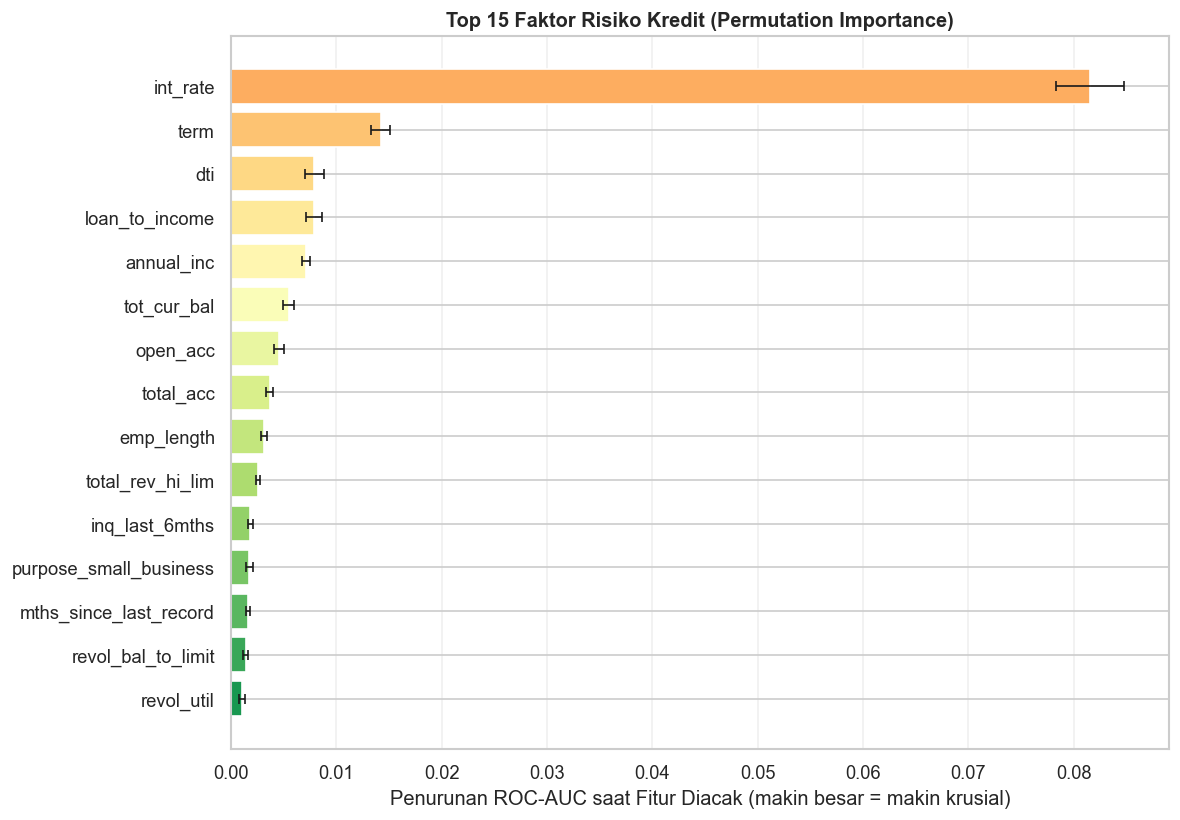

In [52]:
# Visualisasi Feature Importance 
top15 = feat_imp.head(15).sort_values('Importance')

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top15)))
bars = ax.barh(top15['Fitur'], top15['Importance'], 
               xerr=top15['Std'], color=colors[::-1],
               capsize=3, error_kw={'linewidth': 1})

ax.set_xlabel('Penurunan ROC-AUC saat Fitur Diacak (makin besar = makin krusial)')
ax.set_title('Top 15 Faktor Risiko Kredit (Permutation Importance)', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ─── Summary Final ──────────────────────────────────────────────────────────
print("=" * 65)
print("  RINGKASAN AKHIR MODEL CREDIT RISK")
print("=" * 65)
print()
print(f"  Model           : HistGradientBoostingClassifier + Platt Scaling")
print(f"  ROC-AUC (Test)  : {auc_final:.4f}")
print(f"  KS Statistic    : {ks_final:.2%}")
print(f"  Threshold Bisnis: {BEST_THRESHOLD}")
print()
print(f"  Jumlah fitur    : {X_train.shape[1]}")
print(f"  Data training   : {len(X_train):,} baris")
print(f"  Data test       : {len(X_test):,} baris")
print()
print("  ✅ Model siap digunakan sebagai decision support tool")
print("  ⚠️  Threshold final harus dikalibrasi bersama tim bisnis")
print("      berdasarkan analisis biaya NPL vs opportunity cost")
print()
print("  Top 3 Faktor Risiko Kredit:")
for _, row in feat_imp.head(3).iterrows():
    print(f"    {row['Fitur']}: AUC drop {row['Importance']:.4f}")


  RINGKASAN AKHIR MODEL CREDIT RISK

  Model           : HistGradientBoostingClassifier + Platt Scaling
  ROC-AUC (Test)  : 0.7151
  KS Statistic    : 31.37%
  Threshold Bisnis: 0.3

  Jumlah fitur    : 102
  Data training   : 142,617 baris
  Data test       : 47,539 baris

  ✅ Model siap digunakan sebagai decision support tool
  ⚠️  Threshold final harus dikalibrasi bersama tim bisnis
      berdasarkan analisis biaya NPL vs opportunity cost

  Top 3 Faktor Risiko Kredit:
    int_rate: AUC drop 0.0828
    term_60.0: AUC drop 0.0142
    dti: AUC drop 0.0082
